Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [ ]:
# Necessary for the entire / most of the development lifecycle
import pandas as pd
import numpy as np
import sklearn as skl

# For Data extraction
from sklearn.model_selection import train_test_split

# For EDA
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

# For Pre-processing
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# For Model training
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
# For Model evaluation
from sklearn.metrics import \
  r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/Car details v3.csv')

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


Data Preparation

In [ ]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [ ]:
df = df.drop(columns=['torque'])

In [ ]:
df["mileage_kmpl"] = df["mileage"].str.split(" ").str[0].astype(float)
df["engine_cc"] = df["engine"].str.split(" ").str[0].astype(float)
df["max_power"] = df["max_power"].str.split(" ").str[0]
df['max_power_bhp'] = pd.to_numeric(df['max_power'], errors='coerce') #convert to numeric and replace str value with nan
df.drop("mileage", axis=1, inplace=True)
df.drop("engine", axis=1, inplace=True)
df.drop("max_power", axis=1, inplace=True)

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   seats          7907 non-null   float64
 9   mileage_kmpl   7907 non-null   float64
 10  engine_cc      7907 non-null   float64
 11  max_power_bhp  7912 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 762.1+ KB


In [ ]:
df.shape

(8128, 12)

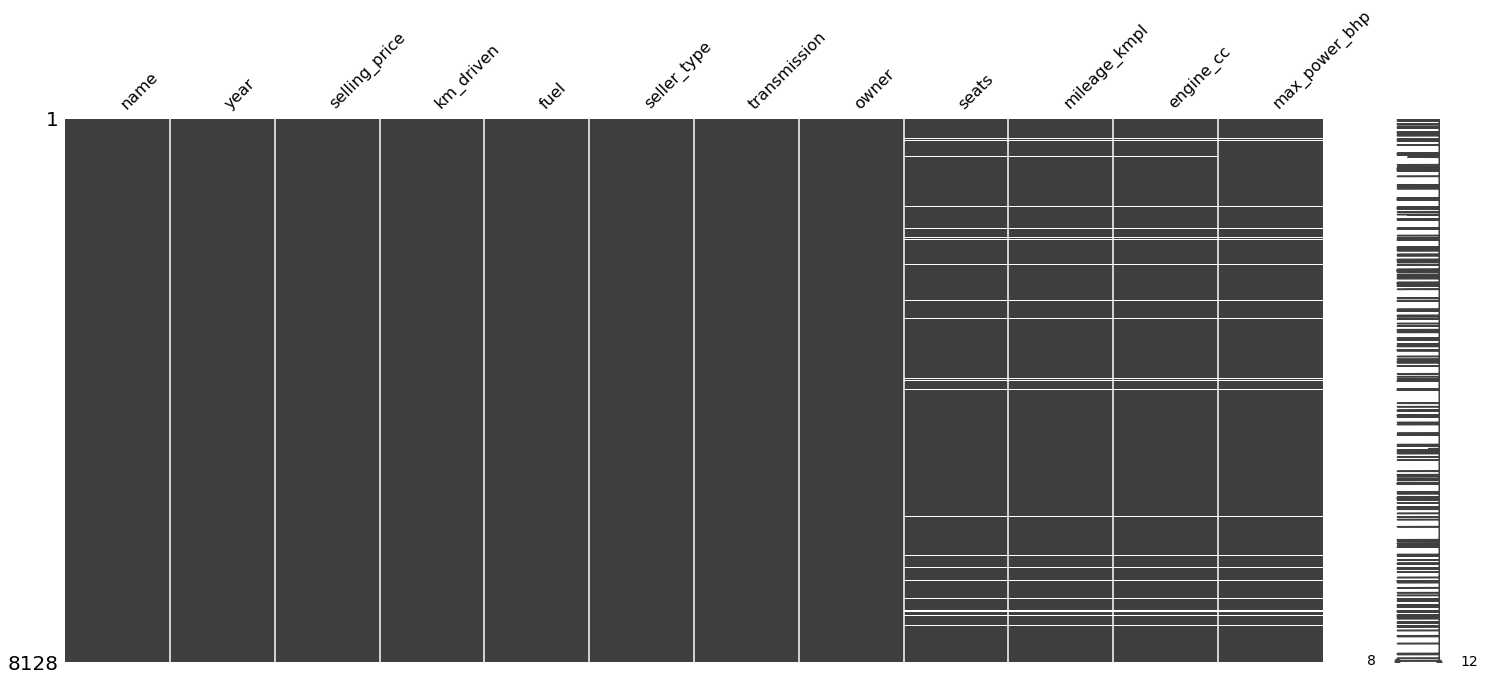

In [ ]:
msno.matrix(df)

In [ ]:
df.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
seats            221
mileage_kmpl     221
engine_cc        221
max_power_bhp    216
dtype: int64

In [ ]:
df = df.dropna()

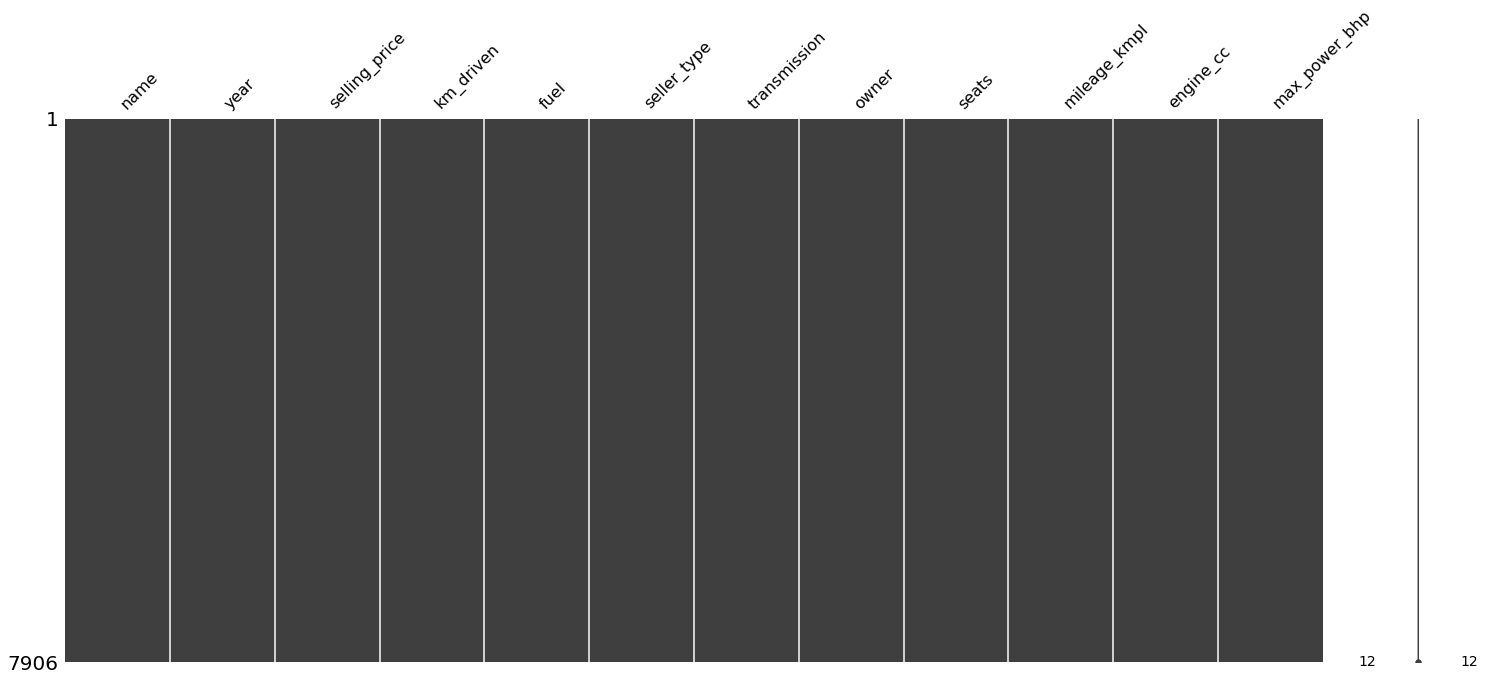

In [ ]:
msno.matrix(df)

In [ ]:
df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
seats            0
mileage_kmpl     0
engine_cc        0
max_power_bhp    0
dtype: int64

In [ ]:
df['name'].str.split(' ', n=1)

0             [Maruti, Swift Dzire VDI]
1       [Skoda, Rapid 1.5 TDI Ambition]
2           [Honda, City 2017-2020 EXi]
3          [Hyundai, i20 Sportz Diesel]
4             [Maruti, Swift VXI BSIII]
                     ...               
8123               [Hyundai, i20 Magna]
8124           [Hyundai, Verna CRDi SX]
8125          [Maruti, Swift Dzire ZDi]
8126                 [Tata, Indigo CR4]
8127                 [Tata, Indigo CR4]
Name: name, Length: 7906, dtype: object

In [ ]:
df[['brand','model']] = df['name'].str.split(' ', n=1, expand=True)
df = df.drop(columns = ['name'])
df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,Maruti,Swift Dzire VDI
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,Skoda,Rapid 1.5 TDI Ambition
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,Honda,City 2017-2020 EXi
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,Hyundai,i20 Sportz Diesel
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,Maruti,Swift VXI BSIII
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,2013,320000,110000,Petrol,Individual,Manual,First Owner,5.0,18.50,1197.0,82.85,Hyundai,i20 Magna
8124,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,5.0,16.80,1493.0,110.00,Hyundai,Verna CRDi SX
8125,2009,382000,120000,Diesel,Individual,Manual,First Owner,5.0,19.30,1248.0,73.90,Maruti,Swift Dzire ZDi
8126,2013,290000,25000,Diesel,Individual,Manual,First Owner,5.0,23.57,1396.0,70.00,Tata,Indigo CR4


In [ ]:
df.shape

(7906, 13)

In [ ]:
df_cars.head()

NameError: ignored

In [ ]:
X = df.drop(labels=["selling_price"], axis=1)
Y = df["selling_price"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=42)
print(f"X_train\nShape: {X_train.shape}\n\nX_test\nShape: {X_test.shape}\n")
print(f"Y_train\nShape: {Y_train.shape}\n\nY_test\nShape: {Y_test.shape}\n")

X_train
Shape: (6324, 12)

X_test
Shape: (1582, 12)

Y_train
Shape: (6324,)

Y_test
Shape: (1582,)



In [ ]:
X_train.head()

,year,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model
3064,2006,62900,Petrol,Individual,Manual,First Owner,5.0,18.90,998.0,67.1,Maruti,Wagon R VXI
2522,2013,95000,Diesel,Individual,Manual,First Owner,5.0,20.46,1461.0,83.8,Renault,Duster 85PS Diesel RxL Optional
1819,2017,38000,Petrol,Individual,Manual,First Owner,5.0,23.01,999.0,67.0,Renault,KWID 1.0 RXT 02 Anniversary Edition
6600,2015,70000,Diesel,Individual,Manual,Third Owner,7.0,15.40,2179.0,120.0,Mahindra,Scorpio S10 7 Seater
7909,2018,9500,Diesel,Individual,Manual,First Owner,5.0,21.50,1497.0,108.5,Tata,Nexon 1.5 Revotorq XM


In [ ]:
Y_train.head()

3064    135000
2522    490000
1819    325000
6600    900000
7909    850000
Name: selling_price, dtype: int64

In [ ]:
df_train = pd.merge(X_train, Y_train, left_index=True, right_index=True)
df_train.head()

,year,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model,selling_price
3064,2006,62900,Petrol,Individual,Manual,First Owner,5.0,18.90,998.0,67.1,Maruti,Wagon R VXI,135000
2522,2013,95000,Diesel,Individual,Manual,First Owner,5.0,20.46,1461.0,83.8,Renault,Duster 85PS Diesel RxL Optional,490000
1819,2017,38000,Petrol,Individual,Manual,First Owner,5.0,23.01,999.0,67.0,Renault,KWID 1.0 RXT 02 Anniversary Edition,325000
6600,2015,70000,Diesel,Individual,Manual,Third Owner,7.0,15.40,2179.0,120.0,Mahindra,Scorpio S10 7 Seater,900000
7909,2018,9500,Diesel,Individual,Manual,First Owner,5.0,21.50,1497.0,108.5,Tata,Nexon 1.5 Revotorq XM,850000


EDA

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


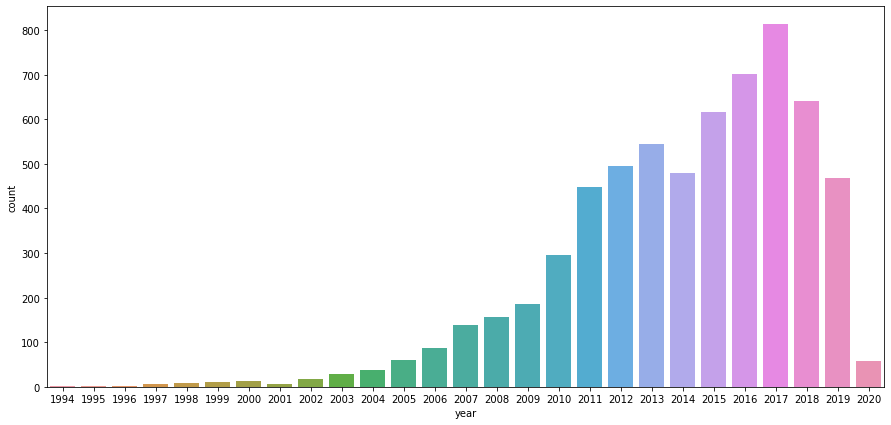

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['year'])
plt.show()

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


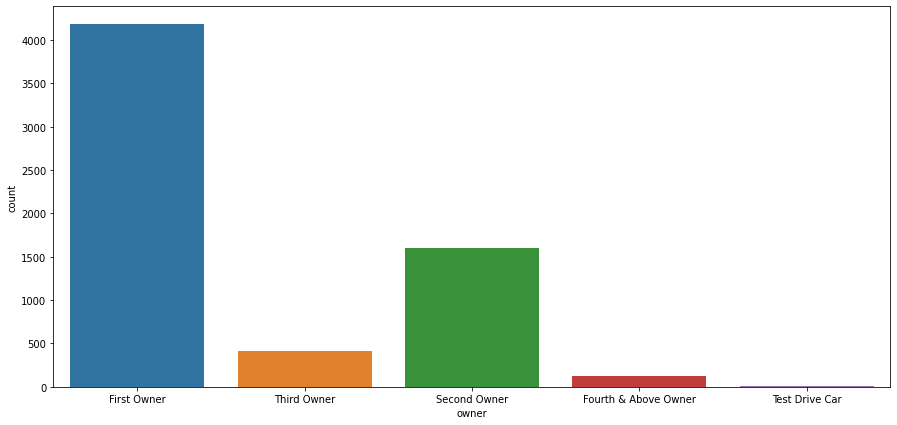

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['owner'])
plt.show()

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


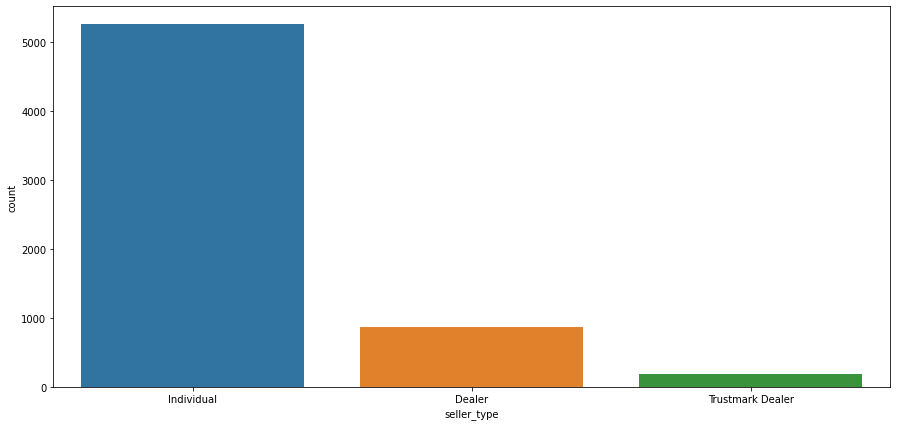

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['seller_type'])
plt.show()

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


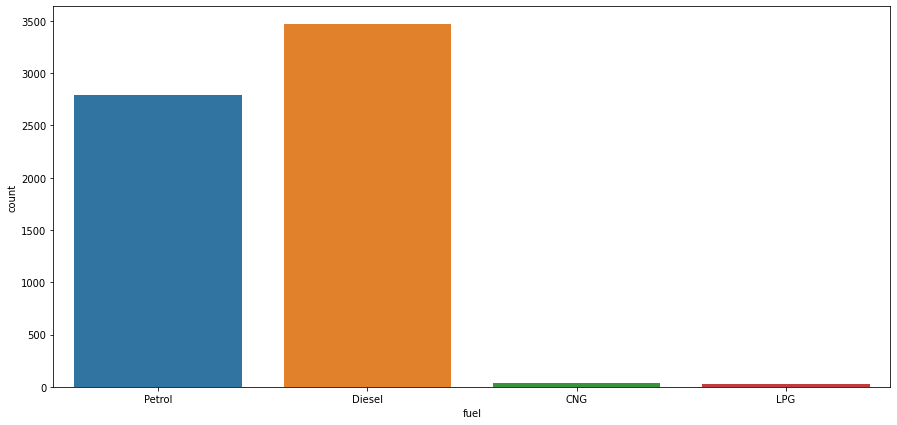

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['fuel'])
plt.show()

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


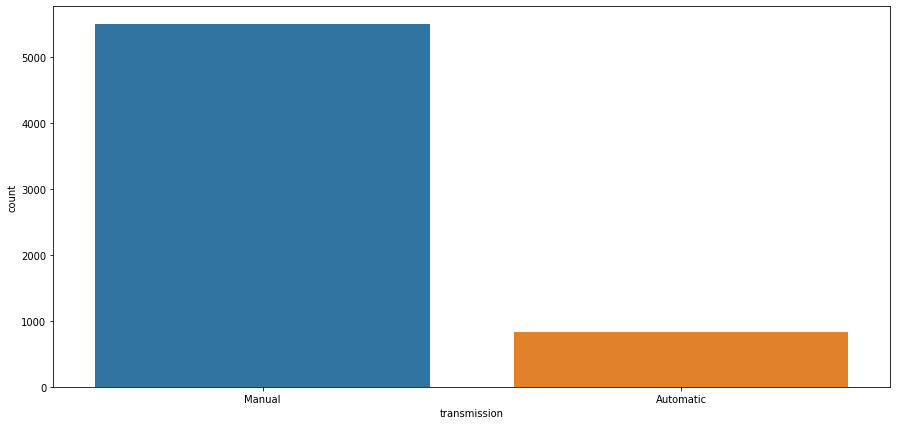

In [ ]:
plt.figure(figsize = (15,7))
sns.countplot(df_train['transmission'])
plt.show()

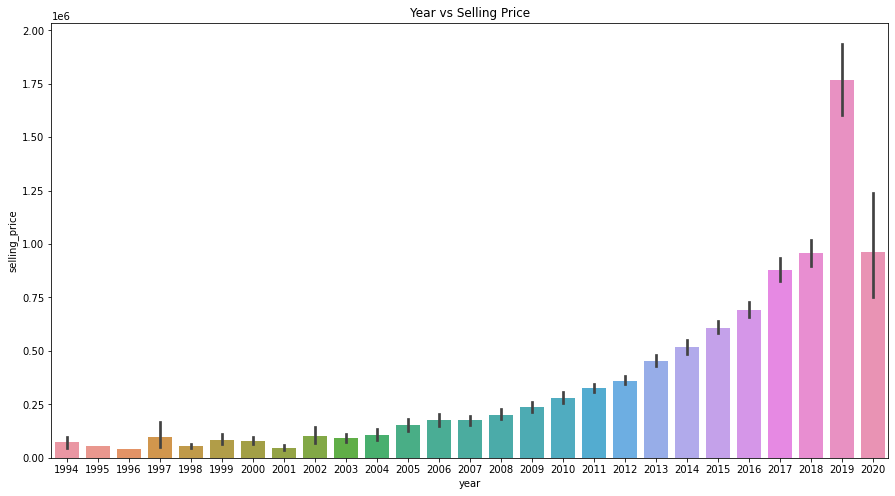

In [ ]:
# relation between year and selling price
plt.figure(figsize=(15,8))
plt.title("Year vs Selling Price")
sns.barplot(data= df_train, x="year", y="selling_price")
plt.show()

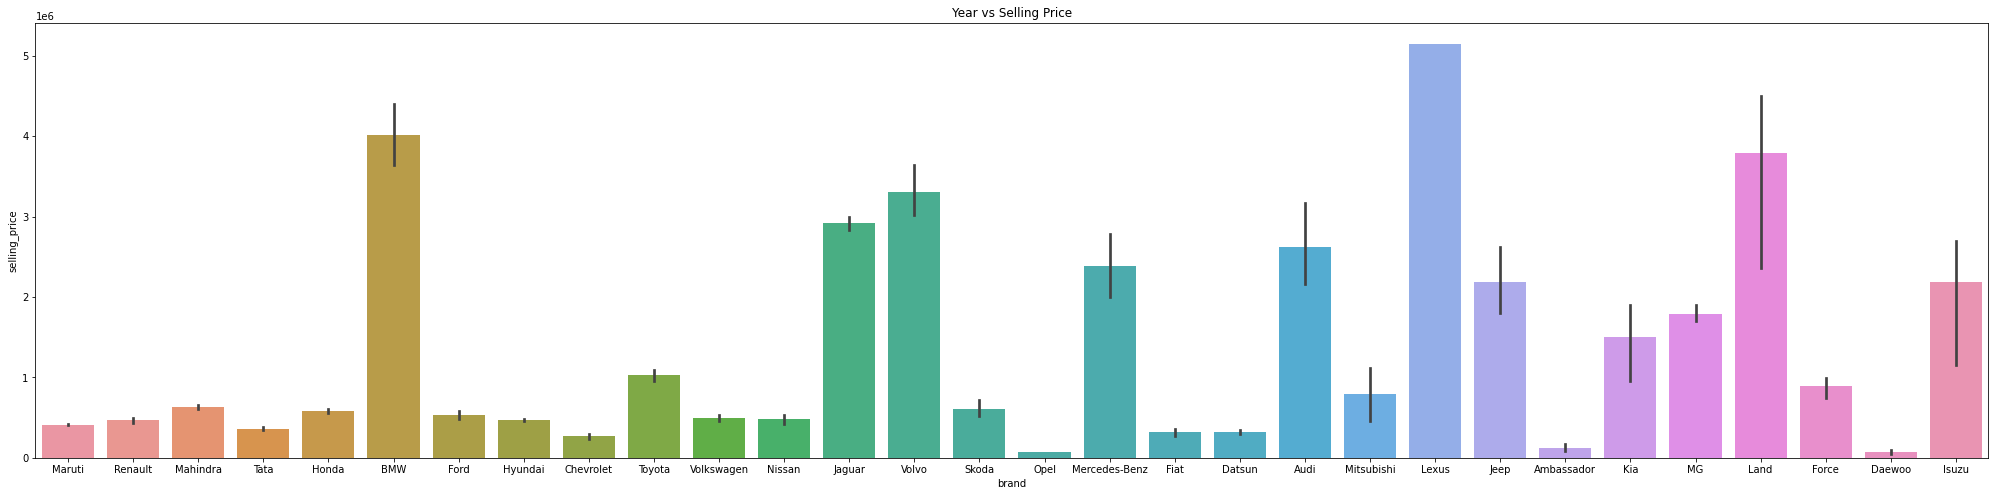

In [ ]:
# relation between year and selling price
plt.figure(figsize=(35,8))
plt.title("Year vs Selling Price")
sns.barplot(data= df_train, x="brand", y="selling_price")
plt.show()

In [ ]:
df_train.loc[df_train['year'].isin([2007])]

,year,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model,selling_price
1264,2007,78000,Petrol,Individual,Manual,Second Owner,5.0,16.10,1298.0,88.20,Maruti,Swift Glam,170000
4503,2007,70000,Petrol,Individual,Manual,Second Owner,5.0,19.81,1086.0,68.05,Hyundai,i10 Era,190000
7401,2007,100000,Diesel,Individual,Manual,Second Owner,5.0,16.60,1896.0,122.40,Skoda,Octavia L and K 1.9 TDI (MT),250000
6936,2007,110000,Diesel,Individual,Manual,Third Owner,5.0,16.80,1405.0,62.00,Tata,Indica V2 DLS TC,80000
4701,2007,90000,Diesel,Individual,Manual,Third Owner,5.0,17.20,1396.0,53.50,Tata,Indica V2 DLE BSII,90000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8041,2007,110000,Petrol,Individual,Manual,Fourth & Above Owner,5.0,18.90,1061.0,67.00,Maruti,Wagon R LXI Minor,90000
3460,2007,80000,Petrol,Individual,Manual,Second Owner,5.0,18.20,1061.0,64.00,Maruti,Zen Estilo 1.1 LX BSIII,70000
5577,2007,90000,Petrol,Individual,Manual,Second Owner,5.0,19.70,796.0,46.30,Maruti,Alto LXi,130000
8020,2007,120000,Diesel,Individual,Manual,Third Owner,5.0,17.20,1396.0,53.50,Tata,Indica V2 DLS,65000


In [ ]:
df_train['seats']

3064    5.0
2522    5.0
1819    5.0
6600    7.0
7909    5.0
       ... 
5374    5.0
5544    5.0
888     5.0
7820    4.0
7479    5.0
Name: seats, Length: 6324, dtype: float64

Text(0.5, 1.0, 'selling_price vs mileage')

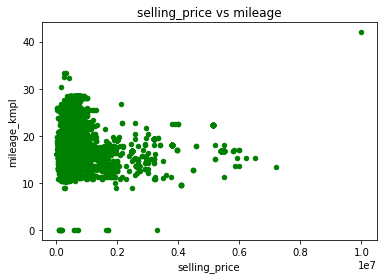

In [ ]:
df_train.plot(kind='scatter',x='selling_price',y='mileage_kmpl', alpha=1, color='green')
plt.xlabel('selling_price')
plt.ylabel('mileage_kmpl')
plt.title('selling_price vs mileage')

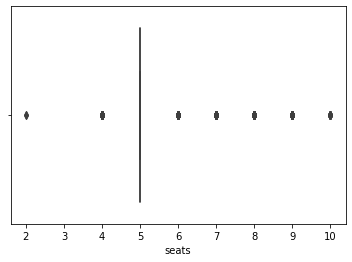

In [ ]:
sns.boxplot(data=df_train,x="seats")

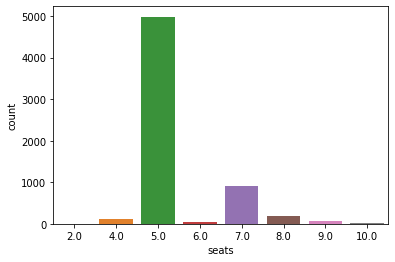

In [ ]:
sns.countplot(data=df_train,x="seats")

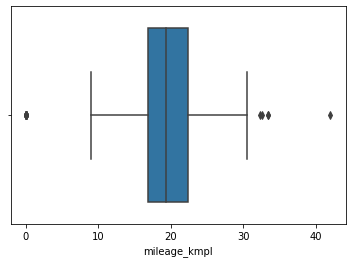

In [ ]:
sns.boxplot(data=df_train,x="mileage_kmpl")

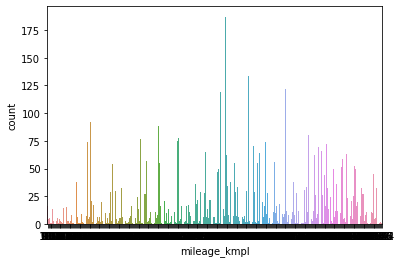

In [ ]:
sns.countplot(data=df_train,x="mileage_kmpl")

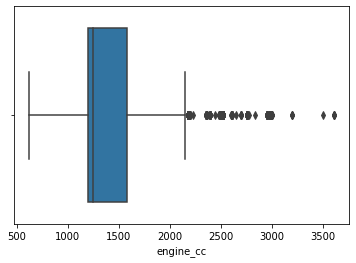

In [ ]:
sns.boxplot(data=df_train,x="engine_cc")

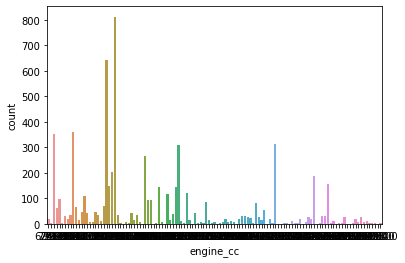

In [ ]:
sns.countplot(data=df_train,x="engine_cc")

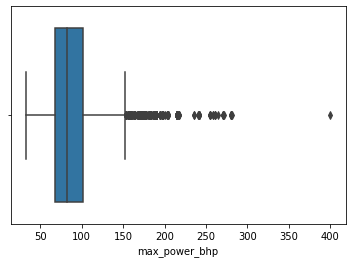

In [ ]:
sns.boxplot(data=df_train,x="max_power_bhp")

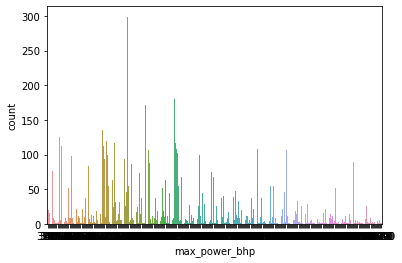

In [ ]:
sns.countplot(data=df_train,x="max_power_bhp")

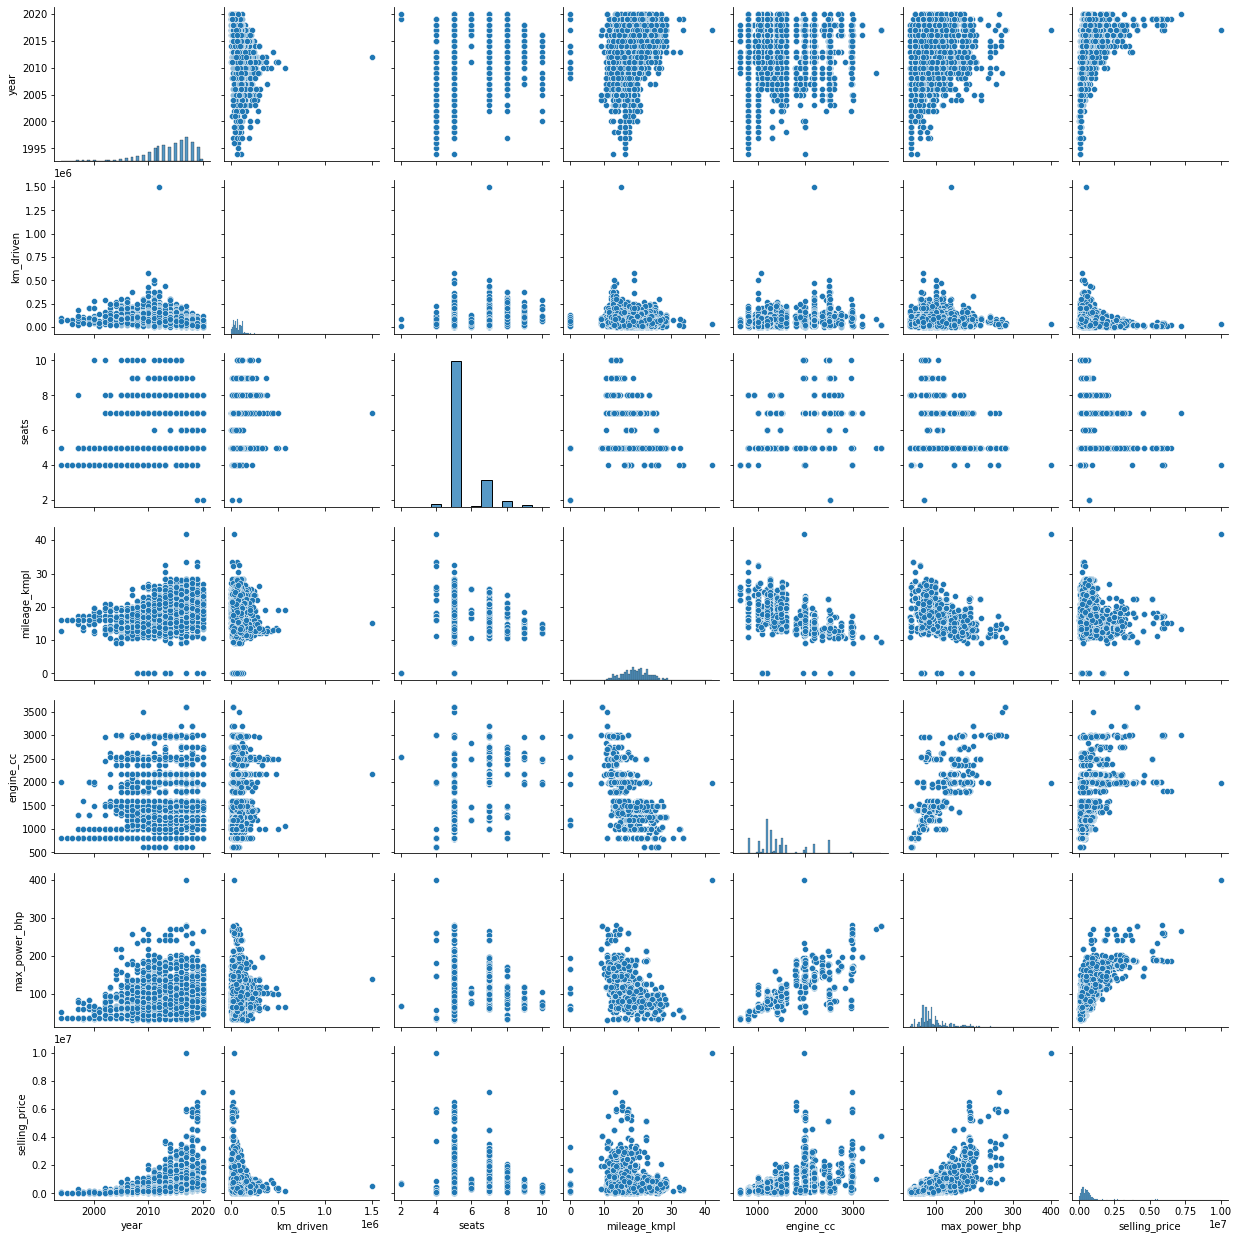

In [ ]:
sns.pairplot(df_train)

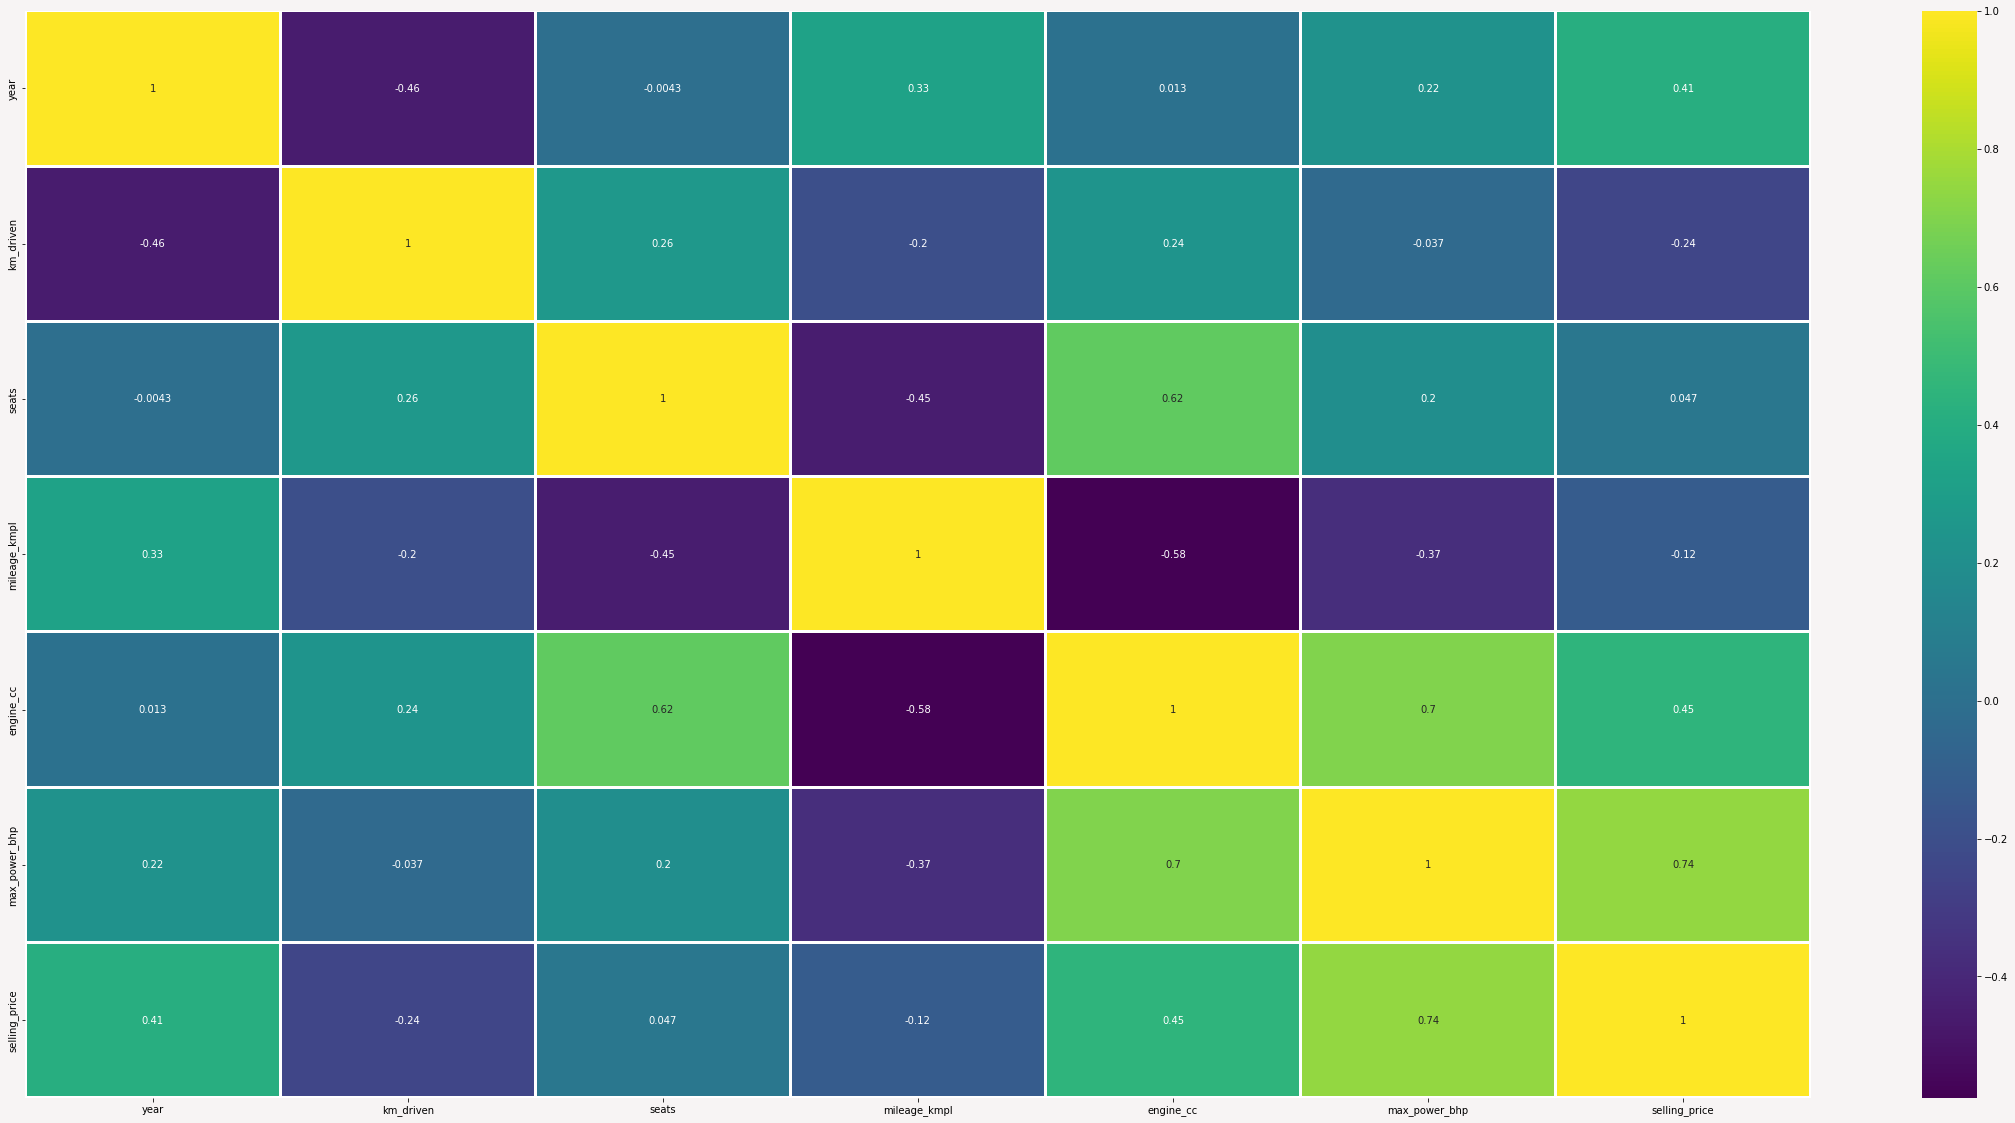

In [ ]:
plt.figure(figsize = [40, 20], facecolor = "#F7F4F4")
sns.heatmap(df_train.corr(), annot = True, linewidths = 2, linecolor = "white", cmap = "viridis");

In [ ]:
df_train.corr().style.background_gradient(cmap = "binary")

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,selling_price
year,1.000000,-0.458744,-0.004275,0.329840,0.013153,0.221623,0.411727
km_driven,-0.458744,1.000000,0.261475,-0.195206,0.236739,-0.037204,-0.243688
seats,-0.004275,0.261475,1.000000,-0.452000,0.618090,0.195394,0.046823
mileage_kmpl,0.329840,-0.195206,-0.452000,1.000000,-0.576006,-0.368838,-0.122355
engine_cc,0.013153,0.236739,0.618090,-0.576006,1.000000,0.701192,0.449784
max_power_bhp,0.221623,-0.037204,0.195394,-0.368838,0.701192,1.000000,0.744020
selling_price,0.411727,-0.243688,0.046823,-0.122355,0.449784,0.744020,1.000000


In [ ]:
df_train.dtypes

year               int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
seats            float64
mileage_kmpl     float64
engine_cc        float64
max_power_bhp    float64
brand             object
model             object
selling_price      int64
dtype: object

In [ ]:
df_train_new = df_train

In [ ]:
X_train = pd.get_dummies(data=X_train, columns=['fuel','seller_type','transmission','owner'])

In [ ]:
X_train.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,model,fuel_CNG,fuel_Diesel,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
3064,2006,62900,5.0,18.90,998.0,67.1,Maruti,Wagon R VXI,0,0,...,0,1,0,0,1,1,0,0,0,0
2522,2013,95000,5.0,20.46,1461.0,83.8,Renault,Duster 85PS Diesel RxL Optional,0,1,...,0,1,0,0,1,1,0,0,0,0
1819,2017,38000,5.0,23.01,999.0,67.0,Renault,KWID 1.0 RXT 02 Anniversary Edition,0,0,...,0,1,0,0,1,1,0,0,0,0
6600,2015,70000,7.0,15.40,2179.0,120.0,Mahindra,Scorpio S10 7 Seater,0,1,...,0,1,0,0,1,0,0,0,0,1
7909,2018,9500,5.0,21.50,1497.0,108.5,Tata,Nexon 1.5 Revotorq XM,0,1,...,0,1,0,0,1,1,0,0,0,0


In [ ]:
X_train = X_train.drop(columns=['brand','model'])
X_train.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
3064,2006,62900,5.0,18.90,998.0,67.1,0,0,0,1,0,1,0,0,1,1,0,0,0,0
2522,2013,95000,5.0,20.46,1461.0,83.8,0,1,0,0,0,1,0,0,1,1,0,0,0,0
1819,2017,38000,5.0,23.01,999.0,67.0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
6600,2015,70000,7.0,15.40,2179.0,120.0,0,1,0,0,0,1,0,0,1,0,0,0,0,1
7909,2018,9500,5.0,21.50,1497.0,108.5,0,1,0,0,0,1,0,0,1,1,0,0,0,0


In [ ]:
X_train.shape

(6324, 20)

In [ ]:
X_train.head()

,year,km_driven,seats,mileage_kmpl,engine_cc,max_power_bhp,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
3064,2006,62900,5.0,18.90,998.0,67.1,0,0,0,1,0,1,0,0,1,1,0,0,0,0
2522,2013,95000,5.0,20.46,1461.0,83.8,0,1,0,0,0,1,0,0,1,1,0,0,0,0
1819,2017,38000,5.0,23.01,999.0,67.0,0,0,0,1,0,1,0,0,1,1,0,0,0,0
6600,2015,70000,7.0,15.40,2179.0,120.0,0,1,0,0,0,1,0,0,1,0,0,0,0,1
7909,2018,9500,5.0,21.50,1497.0,108.5,0,1,0,0,0,1,0,0,1,1,0,0,0,0


In [ ]:
lrg_reg = LinearRegression()
lrg_reg.fit(X_train_input, Y_train_input)

LinearRegression()

In [ ]:
lrg_train_pred = lrg_reg.predict(X_train_input)

In [ ]:
lrg_train_r2 = r2_score(Y_train_input, lrg_train_pred)
lrg_train_mse = mean_squared_error(Y_train_input, lrg_train_pred)
lrg_train_mae = mean_absolute_error(Y_train_input, lrg_train_pred)
print(
f"""
R^2 score: {lrg_train_r2}
lrg_train_mse: {lrg_train_mse}    
lrg_train_mae: {lrg_train_mae}    
"""
)


R^2 score: 0.6827406084857699
lrg_train_mse: 207317529005.32004    
lrg_train_mae: 272782.7218713584    

